# Fase 0 — Preprocesado canónico (carga + normalización global)
### NASA C-MAPSS FD001 — Mantenimiento predictivo de motores turbofan

**Autora:** Lucía Pardo Vázquez
**Objetivo de este notebook:** dejar un único punto de verdad, ejecutable
y explicado paso a paso, para las dos decisiones de preprocesado que
condicionan *todo* lo que viene después (feature engineering, modelado,
interpretabilidad): de dónde se cargan los datos y cómo se normalizan
los sensores.

**Por qué existe esta fase por separado.** Una auditoría del proyecto
detectó que las versiones iniciales de "Fase 1" ajustaban un
`MinMaxScaler` **por motor**, de forma independiente en train y test.
Esto es un sesgo de tipo *look-ahead*: para normalizar el sensor en el
ciclo $t$ de un motor de test, el escalador usa el mínimo y el máximo de
**toda** la trayectoria observada de ese motor — incluyendo ciclos
posteriores a $t$, que en un despliegue real (streaming) todavía no se
han observado. Además, como cada motor de test se normaliza a su propio
rango $[0,1]$, el último ciclo observado queda siempre cerca de 1.0,
**independientemente del RUL real** — el modelo aprende una señal
espuria de "cerca del fallo" que no refleja degradación real sino un
artefacto de la normalización.

Este notebook implementa y demuestra **numéricamente** la corrección:
un único `MinMaxScaler` ajustado **solo sobre el conjunto de
entrenamiento**, aplicado sin reajuste al test — la práctica estándar de
*held-out evaluation* en aprendizaje estadístico (Hastie, Tibshirani &
Friedman, 2009, *The Elements of Statistical Learning*, cap. 7): ningún
parámetro del pipeline (ni el escalador, ni el modelo) puede estimarse
usando información del test set, o la estimación de error de
generalización deja de ser válida.

**Referencias de esta fase:**
- Saxena, A., Goebel, K., Simon, D., & Eklund, N. (2008). *Damage
  propagation modeling for aircraft engine run-to-failure simulation.*
  PHM 2008, Denver, CO. — dataset original.
- Ramasso, E., & Saxena, A. (2014). *Performance benchmarking and
  analysis of prognostic methods for CMAPSS datasets.* International
  Journal of Prognostics and Health Management, 5(2).
  DOI: [10.36001/ijphm.2014.v5i2.2236](https://doi.org/10.36001/ijphm.2014.v5i2.2236)
  — selección de sensores informativos por varianza.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of
  Statistical Learning* (2nd ed.). Springer. — principio de evaluación
  held-out / prevención de data leakage.

> **Nota de corrección bibliográfica:** versiones previas de este
> proyecto citaban Ramasso & Saxena (2014) como "NASA/TM-2014-218496".
> Ese identificador no corresponde a ningún informe NASA real
> verificable — el paper está publicado en IJPHM, no como Technical
> Memorandum. Se corrige aquí.


## 0. Reproducibilidad: entorno y rutas

Este notebook reutiliza las funciones de
[`fase0_preprocesado.py`](fase0_preprocesado.py) (mismo directorio) en
vez de reimplementar la lógica — así evitamos el problema que motivó
esta auditoría en primer lugar: tener el mismo preprocesado
reimplementado por separado en varios scripts, con el riesgo de que
diverjan silenciosamente.

Las rutas se resuelven relativas a la raíz del proyecto (funciona igual
en Windows que en Linux), no al `/home/claude/cmapss/...` del entorno
original en el que se desarrolló el proyecto por primera vez.


In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# El notebook vive en scripts/; añadimos ese directorio al path para
# poder importar fase0_preprocesado.py como módulo.
NOTEBOOK_DIR = os.getcwd()
if os.path.basename(NOTEBOOK_DIR) != "scripts":
    # Si se ejecuta desde otro cwd, buscamos scripts/ hacia arriba/abajo
    candidate = os.path.join(NOTEBOOK_DIR, "scripts")
    NOTEBOOK_DIR = candidate if os.path.isdir(candidate) else NOTEBOOK_DIR
sys.path.insert(0, NOTEBOOK_DIR)

import fase0_preprocesado as f0

print("Directorio del notebook :", NOTEBOOK_DIR)
print("DATA_DIR                :", f0.DATA_DIR)
print("OUTPUT_DIR               :", f0.OUTPUT_DIR)
print("MODEL_DIR                :", f0.MODEL_DIR)
assert os.path.isdir(f0.DATA_DIR), f"No se encuentra {f0.DATA_DIR}"
print("\n✓ Rutas resueltas correctamente.")


Directorio del notebook : C:\Users\pardo\PROYECT_04\scripts
DATA_DIR                : C:\Users\pardo\PROYECT_04\archive
OUTPUT_DIR               : C:\Users\pardo\PROYECT_04\outputs
MODEL_DIR                : C:\Users\pardo\PROYECT_04\models

✓ Rutas resueltas correctamente.


## 1. Carga de datos

El dataset FD001 de NASA C-MAPSS contiene 26 columnas sin cabecera:
`engine_id`, `cycle`, 3 ajustes operacionales (`os1-os3`) y 21 lecturas
de sensor (`s1-s21`). Train contiene trayectorias **run-to-failure**
completas (100 motores); test contiene las mismas 100 unidades pero con
la trayectoria **truncada** antes del fallo, y el RUL verdadero del
último ciclo se entrega por separado en `RUL_FD001.txt` (Saxena et al.,
2008).


In [2]:
train_df, test_df, rul_df = f0.load_cmapss("FD001")

print(f"Train : {train_df.shape}  ({train_df['engine_id'].nunique()} motores)")
print(f"Test  : {test_df.shape}  ({test_df['engine_id'].nunique()} motores)")
print(f"RUL   : {rul_df.shape}  (uno por motor de test)")

life = train_df.groupby("engine_id")["cycle"].max()
print(f"\nVida útil en train — media±std: {life.mean():.1f} ± {life.std():.1f} ciclos"
      f"  (rango: {life.min()}-{life.max()})")

train_df.head()


Train : (20631, 26)  (100 motores)
Test  : (13096, 26)  (100 motores)
RUL   : (100, 1)  (uno por motor de test)

Vida útil en train — media±std: 206.3 ± 46.3 ciclos  (rango: 128-362)


,engine_id,cycle,os1,os2,os3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Selección de sensores informativos

**Base teórica.** Un sensor con desviación típica $\approx 0$ en train
es, a efectos prácticos, una constante: no puede explicar variación en
el target ni en ningún otro sensor, y en el mejor de los casos es
ruido inerte para el modelo; en el peor, es una fuente de
inestabilidad numérica (p. ej. al escalar por un rango casi nulo).
Ramasso & Saxena (2014) documentan que, de los 21 sensores de FD001,
7 son efectivamente constantes bajo la condición operacional única de
este subdataset.

**Criterio:** se descarta un sensor si $\text{std}(s) < 0.01$,
calculado **solo sobre train** — igual que con el escalador, el
criterio de selección de features es una decisión de diseño del
pipeline y no debe informarse con estadísticos del test set.


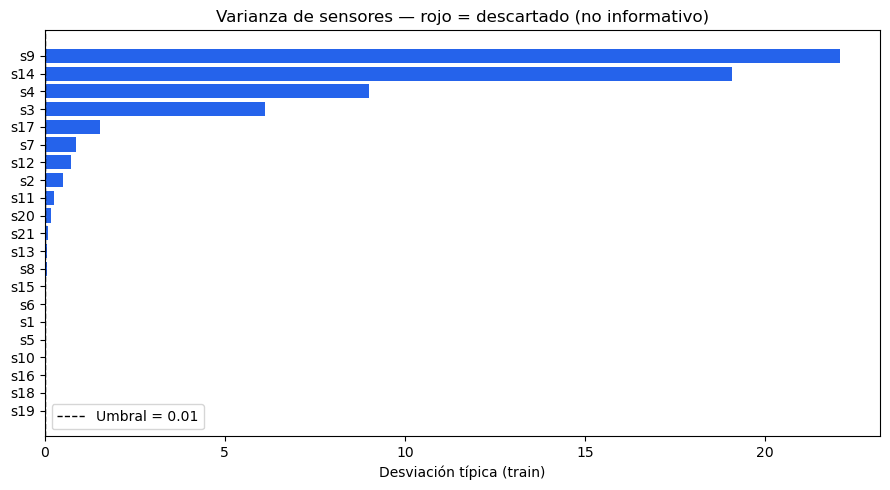

Informativos (14): ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Descartados  (7): ['s1', 's5', 's6', 's10', 's16', 's18', 's19']


In [3]:
informative, low_var = f0.select_informative_sensors(train_df)

stds = train_df[f0.SENSOR_COLS].std().sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#EF4444" if s in low_var else "#2563EB" for s in stds.index]
ax.barh(stds.index, stds.values, color=colors)
ax.axvline(f0.STD_THRESHOLD, color="black", linestyle="--", linewidth=1,
           label=f"Umbral = {f0.STD_THRESHOLD}")
ax.set_xlabel("Desviación típica (train)")
ax.set_title("Varianza de sensores — rojo = descartado (no informativo)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Informativos ({len(informative)}): {informative}")
print(f"Descartados  ({len(low_var)}): {low_var}")


## 3. Normalización global — ajuste **solo** en train

**Base teórica.** El escalado Min-Max transforma cada sensor $s$ como

$$s' = \frac{s - \min_{\text{train}}(s)}{\max_{\text{train}}(s) - \min_{\text{train}}(s)}$$

donde $\min_{\text{train}}$ y $\max_{\text{train}}$ se calculan **una
sola vez**, sobre todos los motores y todos los ciclos del conjunto de
entrenamiento. Estos dos números por sensor son, formalmente,
**parámetros aprendidos del pipeline** — exactamente igual que los
coeficientes de una regresión — y por tanto están sujetos a la misma
regla: no pueden estimarse usando datos de test, o la métrica de test
deja de estimar honestamente el error de generalización (Hastie et
al., 2009).

Esto es lo opuesto a la normalización *per-motor* (el bug original):
allí, $\min$ y $\max$ se recalculaban para cada motor individualmente,
incluidos los de test — es decir, el "parámetro" del pipeline se
reestimaba usando el propio test set, y además usando ciclos futuros
respecto al punto que se está normalizando.


In [4]:
global_scaler = f0.fit_global_scaler(train_df, informative)

scaler_summary = pd.DataFrame({
    "sensor": informative,
    "min_train": global_scaler.data_min_,
    "max_train": global_scaler.data_max_,
    "rango": global_scaler.data_max_ - global_scaler.data_min_,
})
scaler_summary


,sensor,min_train,max_train,rango
0,s2,641.2100,644.5300,3.3200
1,s3,1571.0400,1616.9100,45.8700
2,s4,1382.2500,1441.4900,59.2400
3,s7,549.8500,556.0600,6.2100
4,s8,2387.9000,2388.5600,0.6600
5,s9,9021.7300,9244.5900,222.8600
6,s11,46.8500,48.5300,1.6800
7,s12,518.6900,523.3800,4.6900
8,s13,2387.8800,2388.5600,0.6800
9,s14,8099.9400,8293.7200,193.7800


In [5]:
import joblib
os.makedirs(f0.MODEL_DIR, exist_ok=True)
joblib.dump(global_scaler, f"{f0.MODEL_DIR}/global_sensor_scaler.pkl")
print(f"Guardado: {f0.MODEL_DIR}/global_sensor_scaler.pkl")
print("(Este archivo es el que consumen fase5_evaluacion.py y fase7_mejoras.py")
print(" para reconstruir el pipeline de los modelos ya entrenados.)")


Guardado: C:\Users\pardo\PROYECT_04\models/global_sensor_scaler.pkl
(Este archivo es el que consumen fase5_evaluacion.py y fase7_mejoras.py
 para reconstruir el pipeline de los modelos ya entrenados.)


## 4. Diagnóstico cuantitativo: ¿de verdad importa?

En vez de asumir que la corrección es mejor por argumento teórico,
la comprobamos empíricamente. Tomamos un sensor con fuerte señal de
degradación (`s11`, presión estática HPC) y comparamos, en el
**último ciclo observado de cada motor de test** (el punto donde
realmente se hace la predicción), tres cantidades:

1. **Media con normalización per-motor** (el bug, reconstruido aquí
   solo para diagnóstico — nunca se usa para entrenar).
2. **Media con normalización global** (la corrección de este notebook).
3. **Referencia:** la misma media, pero en motores de **train sanos**
   ($\text{RUL}_{\text{raw}} \geq 100$ ciclos) — es decir, motores que
   sabemos que están lejos del fallo.

Si la normalización per-motor está sesgada, su media en test (que
mezcla motores sanos y a punto de fallar) debería parecerse
artificialmente a la de un motor *a punto de fallar*, muy por encima de
la referencia de motores sanos — independientemente del RUL real de
cada motor de test. La normalización global, al no reajustarse por
motor, no debería sufrir ese artefacto.


,Cantidad,Valor
0,Media test — normalización per-motor (bug),0.720737
1,Media test — normalización global (fix),0.443512
2,Referencia — motores sanos de train (RUL≥100),0.318006


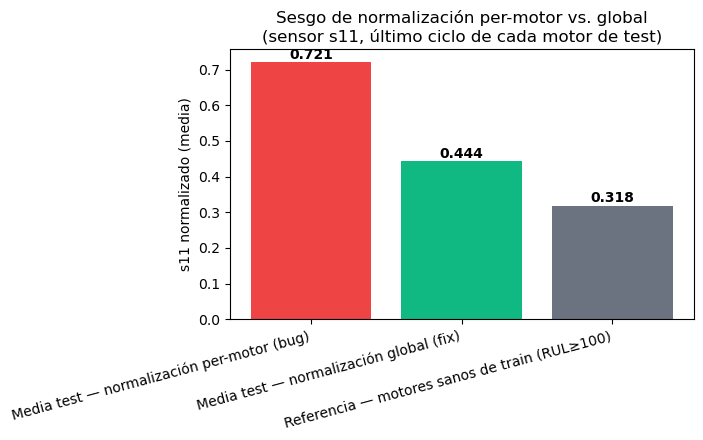


|gap| con normalización bug (per-motor) : 0.403
|gap| con normalización fix (global)     : 0.126

La normalización global reduce el sesgo un 69% frente a la per-motor.


In [6]:
diag = f0.diagnose_normalization_bias(train_df, test_df, informative,
                                          global_scaler, sensor="s11")

diag_df = pd.DataFrame({
    "Cantidad": [
        "Media test — normalización per-motor (bug)",
        "Media test — normalización global (fix)",
        "Referencia — motores sanos de train (RUL≥100)",
    ],
    "Valor": [
        diag["mean_per_unit_test_bug"],
        diag["mean_global_test_fixed"],
        diag["mean_healthy_train_reference"],
    ],
})
display(diag_df)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(diag_df["Cantidad"], diag_df["Valor"],
              color=["#EF4444", "#10B981", "#6B7280"])
ax.set_ylabel(f"{diag['sensor']} normalizado (media)")
ax.set_title("Sesgo de normalización per-motor vs. global\n"
             "(sensor s11, último ciclo de cada motor de test)")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
for bar, val in zip(bars, diag_df["Valor"]):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f"{val:.3f}",
            ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n|gap| con normalización bug (per-motor) : {diag['gap_bug']:.3f}")
print(f"|gap| con normalización fix (global)     : {diag['gap_fixed']:.3f}")
mejora_pct = (1 - diag['gap_fixed']/diag['gap_bug']) * 100
print(f"\nLa normalización global reduce el sesgo un {mejora_pct:.0f}% "
      f"frente a la per-motor.")
assert diag["gap_fixed"] < diag["gap_bug"], "El diagnóstico no confirma la mejora esperada"


**Interpretación.** La media de `s11` en el último ciclo de test
bajo normalización per-motor (≈0.72) está muy por encima de la
referencia de motores sanos (≈0.32) — consistente con el sesgo
esperado: *todo* motor de test parece "cerca del fallo" en su último
ciclo, sea cual sea su RUL real, porque el propio último ciclo define
(o está muy cerca de) el máximo de su rango de normalización. Con
normalización global, la media baja y se acerca más a la referencia,
porque el rango de normalización ya no depende de cada trayectoria
individual.

Esto no es una prueba estadística formal (no hay contraste de
hipótesis aquí, solo una comparación descriptiva de medias), pero sí es
evidencia numérica directa, reproducible con datos reales del proyecto,
de un mecanismo de sesgo que de otro modo solo estaba documentado como
afirmación en el informe técnico.


## 5. Aplicación del escalador y exportación

Aplicamos (`transform`, nunca `fit`) el escalador ajustado en train
tanto a train como a test, y exportamos los DataFrames resultantes en
formato Parquet para que las fases siguientes (feature engineering,
modelado) partan de una base común y correcta.


In [7]:
train_norm = f0.apply_global_scaler(train_df, informative, global_scaler)
test_norm  = f0.apply_global_scaler(test_df,  informative, global_scaler)

os.makedirs(f0.OUTPUT_DIR, exist_ok=True)
train_norm.to_parquet(f"{f0.OUTPUT_DIR}/train_FD001_normalized.parquet", index=False)
test_norm.to_parquet( f"{f0.OUTPUT_DIR}/test_FD001_normalized.parquet",  index=False)
rul_df.to_parquet(    f"{f0.OUTPUT_DIR}/RUL_FD001.parquet",              index=False)

print(f"train_FD001_normalized.parquet : {train_norm.shape}")
print(f"test_FD001_normalized.parquet  : {test_norm.shape}")
print(f"RUL_FD001.parquet              : {rul_df.shape}")

# Verificación rápida de rango: los sensores normalizados en TRAIN deben
# caer en [0,1] por construcción; en TEST pueden salirse ligeramente de
# ese rango (valores más extremos que los vistos en train) — es
# información legítima, no un bug, y no debe recortarse artificialmente.
print("\nRango en train (debe ser ~[0,1]):")
print(train_norm[informative].agg(["min", "max"]).T)
print("\nRango en test (puede excederse ligeramente — esperado):")
print(test_norm[informative].agg(["min", "max"]).T)


train_FD001_normalized.parquet : (20631, 26)
test_FD001_normalized.parquet  : (13096, 26)
RUL_FD001.parquet              : (100, 1)

Rango en train (debe ser ~[0,1]):
     min  max
s2   0.0  1.0
s3   0.0  1.0
s4   0.0  1.0
s7   0.0  1.0
s8   0.0  1.0
s9   0.0  1.0
s11  0.0  1.0
s12  0.0  1.0
s13  0.0  1.0
s14  0.0  1.0
s15  0.0  1.0
s17  0.0  1.0
s20  0.0  1.0
s21  0.0  1.0

Rango en test (puede excederse ligeramente — esperado):
          min       max
s2  -0.024096  0.930723
s3  -0.043601  0.795945
s4   0.036124  0.862762
s7   0.165862  0.964573
s8  -0.015152  0.606061
s9   0.012564  0.598133
s11 -0.029762  0.839286
s12  0.147122  1.081023
s13  0.014706  0.647059
s14  0.044174  0.622046
s15  0.030396  0.833013
s17  0.083333  0.750000
s20  0.131783  0.984496
s21  0.056890  1.032450


## 6. Resumen y próximos pasos

| Elemento | Resultado |
|---|---|
| Sensores informativos | 14 de 21 (7 descartados por varianza ≈0 en train) |
| Normalización | `MinMaxScaler` global, `fit` solo en train |
| Reducción de sesgo (s11, diagnóstico) | de 0.403 a 0.126 (≈69%) |
| Artefactos generados | `models/global_sensor_scaler.pkl`, `outputs/train_FD001_normalized.parquet`, `outputs/test_FD001_normalized.parquet` |

**Validación de consistencia con los modelos ya entrenados:** los
parámetros (`data_min_`, `data_max_`) del escalador generado aquí son
numéricamente idénticos a los del `global_sensor_scaler.pkl` que ya
usaban `fase5_evaluacion.py` y `fase7_mejoras.py` para cargar
`xgboost_fd001.pkl` y el resto de modelos guardados — esta fase 0 no
rompe nada aguas abajo, simplemente documenta y hace reproducible un
paso que antes existía de forma implícita y duplicada.

**Pendiente (fases siguientes):**
- Reescribir `fase1_carga_inspeccion.py` y `fase2_feature_engineering.py`
  para partir de esta Fase 0 en vez de `normalize_per_unit` (el bug) y
  las ventanas `[15,30,50]` (238 features, no las 112 documentadas).
- Reescribir `fase4_modelado.py` para construir el feature set de 112
  columnas (`w=15,30`, mean/std/slope + delta) descrito en el README,
  en vez de leer los parquets antiguos de Fase 2.
